In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
epochs = 100
learning_rate = 1e-3
batch_size = 16

device

device(type='cuda')

## Create dataset

In [9]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
from torch.utils.data import Dataset, DataLoader
import PIL
import os

class CustomDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.data = []
        for file in tqdm(os.listdir(data_path)):
            if file.endswith(".jpg"):
                image = PIL.Image.open(os.path.join(data_path, file))
                image = image.resize((224, 224))
                self.data.append(image)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        if self.transform:
            return self.transform(self.data[idx])
        
        return self.data[idx], 1

dataset = CustomDataset("data", train_transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

  0%|          | 0/142 [00:00<?, ?it/s]

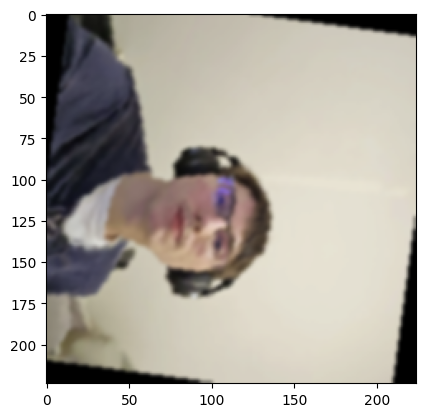

In [11]:
img = dataset[0].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = np.clip(img * std + mean, 0, 1)
plt.imshow(img)
plt.show()

## Train model

In [ ]:
from network import GAN

gan = GAN()

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(gan.parameters(), lr=learning_rate)